# Лабораторная работа 3.4

Решение системы $A x = b$, где $A = A^T > 0$, методом наискорейшего спуска и методом минимальных невязок. Полное условие [здесь](iterative_methods.md).

In [37]:
import time

import matplotlib.pyplot as plt
import numpy as np


np.set_printoptions(precision=6, suppress=True)


def validate_iterative_solver_input(
    A_matrix: np.ndarray,
    b_vector: np.ndarray,
    max_iteration_count: int,
    tolerance: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Проверяет корректность входных данных."""
    matrix_array = np.asarray(A_matrix, dtype=float)
    if matrix_array.ndim != 2:
        raise ValueError("A должна быть матрицей.")

    row_count, column_count = matrix_array.shape
    if row_count != column_count:
        raise ValueError("Матрица A должна быть квадратной.")

    vector_array = np.asarray(b_vector, dtype=float)
    if vector_array.ndim == 2:
        if 1 not in vector_array.shape:
            raise ValueError("b должен быть вектором-столбцом.")
        vector_array = vector_array.reshape(-1)
    elif vector_array.ndim != 1:
        raise ValueError("b должен быть вектором.")

    if vector_array.size != row_count:
        raise ValueError("Размеры матрицы R и вектора b несовместимы.")
    if max_iteration_count <= 0:
        raise ValueError("Максимальное число итераций должно быть положительным.")
    if tolerance <= 0.0:
        raise ValueError("Погрешность должна быть положительной.")

    return matrix_array.copy(), vector_array.copy()


def create_symmetric_positive_definite_matrix(
    matrix_size: int,
    seed: int = 42,
) -> np.ndarray:
    """Строит симметричную положительно определенную матрицу размера n > 100."""
    if matrix_size <= 100:
        raise ValueError("Размер матрицы должен быть n > 100.")

    random_generator = np.random.default_rng(seed)
    base_matrix = random_generator.normal(
        loc=0.0,
        scale=0.35,
        size=(matrix_size, matrix_size),
    )
    spd_matrix = base_matrix.T @ base_matrix
    spd_matrix += 0.5 * np.eye(matrix_size)
    return spd_matrix


def build_b_vector_for_known_solution(
    A_matrix: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Строит вектор b для уравнения Ax = b по заранее известному точному решению."""
    matrix_size = A_matrix.shape[0]
    exact_solution = np.linspace(1.0, 2.0, matrix_size)
    b_vector = A_matrix @ exact_solution
    return b_vector, exact_solution


def solve_linear_system_with_residual_methods(
    A_matrix: np.ndarray,
    b_vector: np.ndarray,
    max_iteration_count: int,
    tolerance: float,
    use_minimal_residual_method: bool,
) -> tuple[np.ndarray, np.ndarray]:
    """Решает систему методом наискорейшего спуска или минимальных невязок."""
    A_copy, b_copy = validate_iterative_solver_input(
        A_matrix,
        b_vector,
        max_iteration_count,
        tolerance,
    )
    approximation = np.zeros(b_copy.size, dtype=float)
    residual = b_copy.copy()
    residual_norm_history = [float(np.linalg.norm(residual))]

    for _ in range(max_iteration_count):
        if residual_norm_history[-1] < tolerance:
            break

        matrix_times_residual = A_copy @ residual
        if use_minimal_residual_method:
            numerator = float(np.dot(matrix_times_residual, residual))
            denominator = float(np.dot(matrix_times_residual, matrix_times_residual))
        else:
            numerator = float(np.dot(residual, residual))
            denominator = float(np.dot(residual, matrix_times_residual))

        if abs(denominator) <= 1e-20:
            raise ZeroDivisionError(
                "Знаменатель в формуле для итерационного параметра tau слишком мал.",
            )

        tau = numerator / denominator
        approximation += tau * residual
        residual -= tau * matrix_times_residual

        residual_norm_history.append(float(np.linalg.norm(residual)))

    return approximation, np.asarray(residual_norm_history, dtype=float)


def compute_solution_difference_norm(
    first_solution: np.ndarray,
    second_solution: np.ndarray,
) -> float:
    """Вычисляет евклидову норму разности двух решений."""
    return float(
        np.linalg.norm(
            np.asarray(first_solution, dtype=float)
            - np.asarray(second_solution, dtype=float)
        )
    )

Размер матрицы: 2000 x 2000
Погрешность решения NumPy = 8.246182961570542e-12
Время работы решения NumPy = 0.13852570799645036 с

Метод наискорейшего спуска
Число итераций = 19299
Итоговая норма невязки = 9.982900847283069e-09
Точная ошибка ||x_custom - x||_2 = 1.4247163776098086e-08
Время работы реализованной функции = 9.025245625001844 с

Метод минимальных невязок
Число итераций = 18962
Итоговая норма невязки = 9.999066266390787e-09
Точная ошибка ||x_custom - x||_2 = 1.9826613666840245e-08
Время работы реализованной функции = 9.344379958005447 с


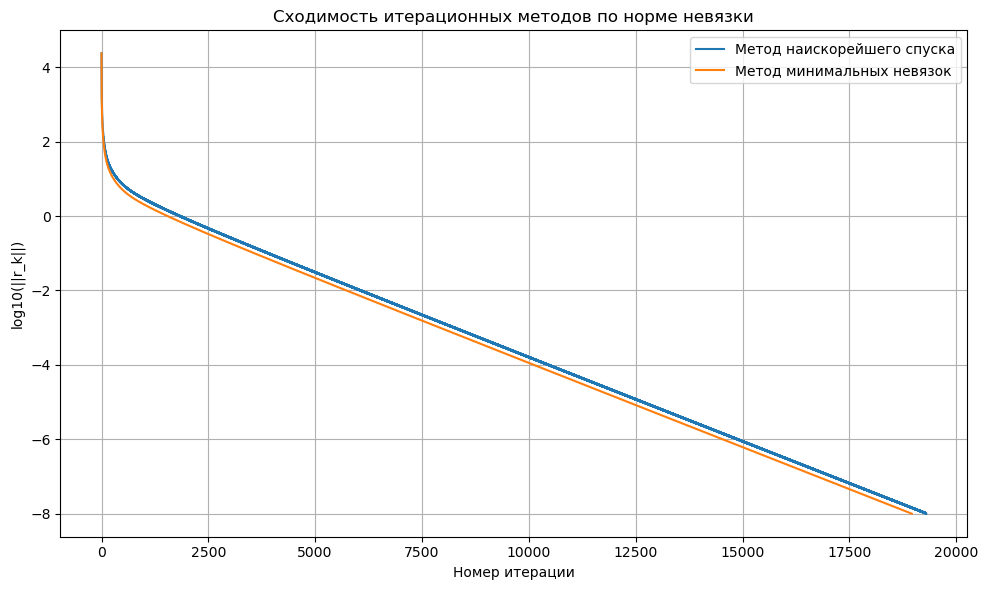

In [38]:
matrix_size = 2000
max_iteration_count = 1000_000
tolerance = 1e-8

A_matrix = create_symmetric_positive_definite_matrix(matrix_size)
b_vector, known_exact_solution = build_b_vector_for_known_solution(
    A_matrix,
)

start_time = time.perf_counter()
numpy_solution = np.linalg.solve(A_matrix, b_vector)
numpy_elapsed_time = time.perf_counter() - start_time

steepest_descent_solution, steepest_descent_residual_history = (
    solve_linear_system_with_residual_methods(
        A_matrix,
        b_vector,
        max_iteration_count,
        tolerance,
        use_minimal_residual_method=False,
    )
)
minimal_residual_solution, minimal_residual_residual_history = (
    solve_linear_system_with_residual_methods(
        A_matrix,
        b_vector,
        max_iteration_count,
        tolerance,
        use_minimal_residual_method=True,
    )
)

numpy_error_norm = compute_solution_difference_norm(
    numpy_solution,
    known_exact_solution,
)
steepest_descent_error_norm = compute_solution_difference_norm(
    steepest_descent_solution,
    known_exact_solution,
)
minimal_residual_error_norm = compute_solution_difference_norm(
    minimal_residual_solution,
    known_exact_solution,
)

start_time = time.perf_counter()
solve_linear_system_with_residual_methods(
    A_matrix,
    b_vector,
    max_iteration_count,
    tolerance,
    use_minimal_residual_method=False,
)
steepest_descent_elapsed_time = time.perf_counter() - start_time

start_time = time.perf_counter()
solve_linear_system_with_residual_methods(
    A_matrix,
    b_vector,
    max_iteration_count,
    tolerance,
    use_minimal_residual_method=True,
)
minimal_residual_elapsed_time = time.perf_counter() - start_time

print(f"Размер матрицы: {matrix_size} x {matrix_size}")
print("Погрешность решения NumPy = " f"{numpy_error_norm}")
print(f"Время работы решения NumPy = {numpy_elapsed_time} с")
print()
print("Метод наискорейшего спуска")
print("Число итераций = " f"{steepest_descent_residual_history.size - 1}")
print("Итоговая норма невязки = " f"{steepest_descent_residual_history[-1]}")
print("Точная ошибка ||x_custom - x||_2 = " f"{steepest_descent_error_norm}")
print("Время работы реализованной функции = " f"{steepest_descent_elapsed_time} с")
print()
print("Метод минимальных невязок")
print("Число итераций = " f"{minimal_residual_residual_history.size - 1}")
print("Итоговая норма невязки = " f"{minimal_residual_residual_history[-1]}")
print("Точная ошибка ||x_custom - x||_2 = " f"{minimal_residual_error_norm}")
print("Время работы реализованной функции = " f"{minimal_residual_elapsed_time} с")

iteration_indices_for_steepest_descent = np.arange(
    steepest_descent_residual_history.size,
)
iteration_indices_for_minimal_residual = np.arange(
    minimal_residual_residual_history.size,
)

plt.figure(figsize=(10, 6))
plt.plot(
    iteration_indices_for_steepest_descent,
    np.log10(
        np.maximum(steepest_descent_residual_history, np.finfo(float).tiny),
    ),
    label="Метод наискорейшего спуска",
)
plt.plot(
    iteration_indices_for_minimal_residual,
    np.log10(
        np.maximum(minimal_residual_residual_history, np.finfo(float).tiny),
    ),
    label="Метод минимальных невязок",
)
plt.title("Сходимость итерационных методов по норме невязки")
plt.xlabel("Номер итерации")
plt.ylabel("log10(||r_k||)")
plt.grid(True)
plt.legend()
plt.tight_layout()

## Вывод

Обе схемы сходятся, поскольку матрица симметрична и положительно определена. Метод наименьших невязок оказался быстрее, а градиентный спуск точнее!